# Fresh Evaluation and Model Comparison

This notebook recomputes evaluation results from the current project files.

It does **not retrain** any model. It loads the existing methods and evaluates them again on the processed dataset:

- Rule-based method
- Traditional Machine Learning method
- Deep Learning method: DeBERTa-v3-base (`microsoft/deberta-v3-base`)

The goal is to show fresh metrics, charts, and simple explanations for the final report or presentation.

## 1. What This Notebook Does

The notebook follows this process:

1. Load the processed restaurant ABSA dataset.
2. Split the dataset into **70% training** and **30% testing**.
3. Retrain the Traditional ML baseline on the 70% training split.
4. Run each method on the same 30% testing split.
5. Compare predictions with the true labels.
6. Calculate accuracy, precision, recall, F1-score, macro F1, and weighted F1.
7. Draw charts to make the result easier to understand.

This notebook uses a held-out testing split so the result shows clearer differences between methods. The Traditional ML method is retrained inside this notebook because it trains quickly. The DeBERTa model is loaded from the saved model folder and evaluated on the same 30% testing split.

In [16]:
from pathlib import Path
import sys
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "evaluation":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "backends":
    PROJECT_ROOT = PROJECT_ROOT.parent

BACKENDS_DIR = PROJECT_ROOT / "backends"
DATASET_PATH = BACKENDS_DIR / "data" / "processed" / "restaurant_absa_4_aspects.csv"

ASPECTS = ["Food", "Service", "Price", "Eating Environment / Ambiance"]
LABELS = ["Positive", "Negative", "Unknown"]

sys.path.insert(0, str(BACKENDS_DIR / "rule_based"))
sys.path.insert(0, str(BACKENDS_DIR / "traditional_ml"))
sys.path.insert(0, str(BACKENDS_DIR / "deep_learning"))

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATASET_PATH)
print("Dataset exists:", DATASET_PATH.exists())

Project root: /Users/kafe/Desktop/NLP_Final Project/absa_v01
Dataset: /Users/kafe/Desktop/NLP_Final Project/absa_v01/backends/data/processed/restaurant_absa_4_aspects.csv
Dataset exists: True


## 2. Load Dataset

The dataset has one row per restaurant review.

Each review has four aspect labels:

- Food
- Service
- Price
- Eating Environment / Ambiance

Each aspect can be `Positive`, `Negative`, or `Unknown`.

In [17]:
df = pd.read_csv(DATASET_PATH, dtype={"id": str})

TEST_SIZE = 0.30
RANDOM_STATE = 42

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

print("Total rows:", len(df))
print("Training rows:", len(train_df), f"({1 - TEST_SIZE:.0%})")
print("Testing rows:", len(test_df), f"({TEST_SIZE:.0%})")
print("Random state:", RANDOM_STATE)

display(df.head())

Total rows: 3041
Training rows: 2128 (70%)
Testing rows: 913 (30%)
Random state: 42


,id,review,Food,Service,Price,Eating Environment / Ambiance
0,3121,But the staff was so horrible to us.,Unknown,Negative,Unknown,Unknown
1,2777,"To be completely fair, the only redeeming fact...",Positive,Unknown,Unknown,Unknown
2,1634,"The food is uniformly exceptional, with a very...",Positive,Unknown,Unknown,Unknown
3,2534,Where Gabriela personaly greets you and recomm...,Unknown,Positive,Unknown,Unknown
4,583,"For those that go once and don't enjoy it, all...",Unknown,Unknown,Unknown,Unknown


## 3. Train/Test Split

This notebook uses a **70% training / 30% testing** split.

The testing split is used for the final charts. This makes the difference between methods clearer because the Traditional ML model is tested on reviews that were not used to train it inside this notebook.

The rule-based method does not need training. The DeBERTa model is already trained, so this notebook only loads it and tests it on the same 30% testing split.

In [18]:
label_counts = []
for aspect in ASPECTS:
    counts = df[aspect].value_counts().reindex(LABELS, fill_value=0)
    for label, count in counts.items():
        label_counts.append({"Aspect": aspect, "Label": label, "Count": int(count)})

label_counts_df = pd.DataFrame(label_counts)
display(label_counts_df.pivot(index="Aspect", columns="Label", values="Count"))

Label,Negative,Positive,Unknown
Aspect,,,
Eating Environment / Ambiance,98,263,2680
Food,209,867,1965
Price,115,179,2747
Service,218,324,2499


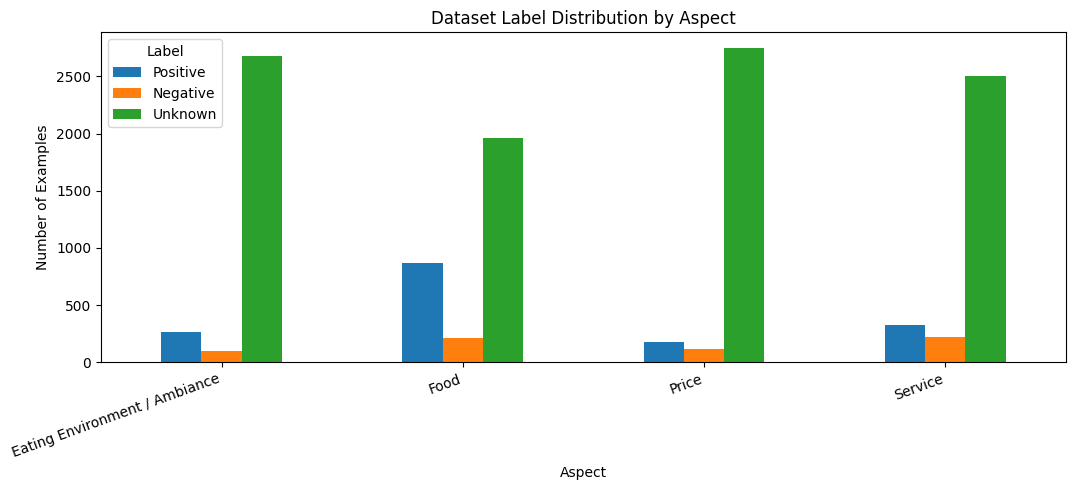

In [19]:
pivot_counts = label_counts_df.pivot(index="Aspect", columns="Label", values="Count")[LABELS]
ax = pivot_counts.plot(kind="bar", figsize=(11, 5))
ax.set_title("Dataset Label Distribution by Aspect")
ax.set_xlabel("Aspect")
ax.set_ylabel("Number of Examples")
ax.legend(title="Label")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 4. Helper Functions

These functions convert each method's output into the same format, then calculate metrics.

The notebook includes **F1-score** in the evaluation tables.

Because this is a multi-class classification task, the displayed `F1-score` means the **macro-averaged F1-score**. This is the same value as `Macro F1`, but it is shown separately because the teacher specifically asked for F1-score.

Macro F1 is important because the dataset is imbalanced. There are many `Unknown` labels, so accuracy alone can look high even when the model is weak on `Positive` and `Negative` labels.

In [20]:
def output_to_dict(output):
    return {item["aspect"]: item["sentiment"] for item in output["results"]}


def evaluate_wide_predictions(name, predictions_by_aspect, data=df):
    """Evaluate one method that returns one prediction per aspect per review."""
    rows = []
    all_true = []
    all_pred = []

    for aspect in ASPECTS:
        y_true = data[aspect].tolist()
        y_pred = predictions_by_aspect[aspect]
        all_true.extend(y_true)
        all_pred.extend(y_pred)

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        )
        weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=LABELS, average="weighted", zero_division=0
        )
        rows.append({
            "Model": name,
            "Aspect": aspect,
            "Accuracy": accuracy_score(y_true, y_pred),
            "Macro Precision": precision,
            "Macro Recall": recall,
            "F1-score": f1,
            "Macro F1": f1,
            "Weighted F1": weighted_f1,
        })

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_true, all_pred, labels=LABELS, average="macro", zero_division=0
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        all_true, all_pred, labels=LABELS, average="weighted", zero_division=0
    )

    overall = {
        "Model": name,
        "Aspect": "Overall",
        "Accuracy": accuracy_score(all_true, all_pred),
        "Macro Precision": precision,
        "Macro Recall": recall,
        "F1-score": f1,
        "Macro F1": f1,
        "Weighted F1": weighted_f1,
    }

    return pd.DataFrame([overall] + rows), all_true, all_pred


def print_runtime(name, start):
    seconds = time.time() - start
    print(f"{name} finished in {seconds:.1f} seconds")

## 5. Evaluate Rule-based Method

The rule-based method uses manually written aspect keywords, sentiment words, negation handling, and dependency parsing.

It does not learn from data. It is useful as a baseline because it is easy to explain line by line, but it usually performs worse than trained models on complex sentences.

In [21]:
rule_based_available = True
rule_based_error = None
rule_metrics = None
rule_true = None
rule_pred = None

try:
    from rule_based_model import predict as rule_predict
    start = time.time()
    predictions = {aspect: [] for aspect in ASPECTS}

    for review in test_df["review"]:
        result = output_to_dict(rule_predict(review))
        for aspect in ASPECTS:
            predictions[aspect].append(result.get(aspect, "Unknown"))

    rule_metrics, rule_true, rule_pred = evaluate_wide_predictions("Rule-based", predictions, data=test_df)
    print_runtime("Rule-based evaluation", start)
    display(rule_metrics)
except Exception as exc:
    rule_based_available = False
    rule_based_error = exc
    print("Rule-based evaluation could not run.")
    print("Reason:", repr(exc))
    print("Most common fix: install spaCy model with: python -m spacy download en_core_web_sm")

Rule-based evaluation finished in 2.8 seconds


,Model,Aspect,Accuracy,Macro Precision,Macro Recall,F1-score,Macro F1,Weighted F1
0,Rule-based,Overall,0.852683,0.804240,0.496642,0.557197,0.557197,0.823129
1,Rule-based,Food,0.736035,0.813779,0.474838,0.511460,0.511460,0.685049
2,Rule-based,Service,0.867470,0.870811,0.515730,0.579615,0.579615,0.835643
3,Rule-based,Price,0.936473,0.907277,0.576999,0.669259,0.669259,0.924162
4,Rule-based,Eating Environment / Ambiance,0.870756,0.607237,0.460218,0.495205,0.495205,0.854513


## 6. Evaluate Traditional Machine Learning Method

The Traditional ML method is retrained inside this notebook on the 70% training split.

This is done because Traditional ML trains quickly, and it gives a fairer 70/30 comparison. The model is then evaluated only on the 30% testing split.

In [22]:
import importlib.util

traditional_train_path = BACKENDS_DIR / "traditional_ml" / "train.py"
spec = importlib.util.spec_from_file_location("traditional_ml_train", traditional_train_path)
traditional_train_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(traditional_train_module)

start = time.time()
traditional_models = {}
traditional_predictions = {}

for aspect in ASPECTS:
    pipeline = traditional_train_module.build_pipeline()
    pipeline.fit(train_df["review"], train_df[aspect])
    traditional_models[aspect] = pipeline
    traditional_predictions[aspect] = pipeline.predict(test_df["review"].tolist()).tolist()

traditional_metrics, traditional_true, traditional_pred = evaluate_wide_predictions(
    "Traditional ML", traditional_predictions, data=test_df
)
print_runtime("Traditional ML 70/30 training and evaluation", start)
display(traditional_metrics)

Traditional ML 70/30 training and evaluation finished in 0.2 seconds


,Model,Aspect,Accuracy,Macro Precision,Macro Recall,F1-score,Macro F1,Weighted F1
0,Traditional ML,Overall,0.877054,0.757850,0.563887,0.613935,0.613935,0.858709
1,Traditional ML,Food,0.810515,0.759444,0.621250,0.659966,0.659966,0.797291
2,Traditional ML,Service,0.866375,0.702908,0.546641,0.586335,0.586335,0.843466
3,Traditional ML,Price,0.927711,0.864946,0.478811,0.548324,0.548324,0.906540
4,Traditional ML,Eating Environment / Ambiance,0.903614,0.767910,0.476585,0.532570,0.532570,0.881542


## 7. Evaluate Deep Learning Method: DeBERTa-v3-base

The deep learning method loads the saved local transformer model from:

`backends/deep_learning/bert_absa_model/`

The actual model is **DeBERTa-v3-base** (`microsoft/deberta-v3-base`).

This section can take longer than the other methods, especially on CPU. It still does not retrain the DeBERTa model; it only runs prediction on the 30% testing split.

In [23]:
RUN_DEBERTA_EVALUATION = True

# Keep this as None for full evaluation.
# If your computer is slow, set it to a smaller number such as 300 first.
DEBERTA_MAX_REVIEWS = None
DEBERTA_BATCH_SIZE = 16

In [24]:
deberta_metrics = None
deberta_true = None
deberta_pred = None
deberta_error = None

if RUN_DEBERTA_EVALUATION:
    try:
        import torch
        from predict_bert import BertAbsaPredictor

        start = time.time()
        eval_df = test_df if DEBERTA_MAX_REVIEWS is None else test_df.head(DEBERTA_MAX_REVIEWS).copy()
        predictor = BertAbsaPredictor()

        deberta_predictions = {aspect: [] for aspect in ASPECTS}
        reviews = eval_df["review"].tolist()

        for i in range(0, len(reviews), DEBERTA_BATCH_SIZE):
            batch_reviews = reviews[i:i + DEBERTA_BATCH_SIZE]
            pair_reviews = []
            pair_aspects = []
            for review in batch_reviews:
                for aspect in ASPECTS:
                    pair_reviews.append(review)
                    pair_aspects.append(aspect)

            encoded = predictor.tokenizer(
                pair_reviews,
                pair_aspects,
                truncation=True,
                padding=True,
                max_length=predictor.max_length,
                return_tensors="pt",
            )
            encoded = {key: value.to(predictor.device) for key, value in encoded.items()}

            with torch.no_grad():
                output = predictor.model(**encoded)
                predicted_ids = output.logits.argmax(dim=-1).cpu().tolist()

            labels = [predictor.id2label[int(label_id)] for label_id in predicted_ids]
            for offset in range(0, len(labels), len(ASPECTS)):
                for aspect, label in zip(ASPECTS, labels[offset:offset + len(ASPECTS)]):
                    deberta_predictions[aspect].append(label)

            if (i // DEBERTA_BATCH_SIZE + 1) % 20 == 0:
                print(f"Processed {min(i + DEBERTA_BATCH_SIZE, len(reviews))}/{len(reviews)} reviews")

        deberta_metrics, deberta_true, deberta_pred = evaluate_wide_predictions(
            "Deep Learning / DeBERTa", deberta_predictions, data=eval_df
        )
        print_runtime("DeBERTa evaluation", start)
        display(deberta_metrics)
    except Exception as exc:
        deberta_error = exc
        print("DeBERTa evaluation could not run.")
        print("Reason:", repr(exc))
        print("Check that torch, transformers, sentencepiece, and the local model folder are available.")
else:
    print("DeBERTa evaluation skipped. Set RUN_DEBERTA_EVALUATION = True to run it.")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Processed 320/913 reviews
Processed 640/913 reviews
DeBERTa evaluation finished in 71.2 seconds


,Model,Aspect,Accuracy,Macro Precision,Macro Recall,F1-score,Macro F1,Weighted F1
0,Deep Learning / DeBERTa,Overall,0.949890,0.887786,0.891859,0.886488,0.886488,0.950648
1,Deep Learning / DeBERTa,Food,0.932092,0.923718,0.883960,0.896970,0.896970,0.932306
2,Deep Learning / DeBERTa,Service,0.941950,0.857679,0.885748,0.869179,0.869179,0.943264
3,Deep Learning / DeBERTa,Price,0.972618,0.892566,0.899882,0.890505,0.890505,0.973151
4,Deep Learning / DeBERTa,Eating Environment / Ambiance,0.952903,0.842556,0.867094,0.853403,0.853403,0.953846


## 8. Overall Model Comparison

This table compares the main result of each method on the 30% testing split.

For the final project, **F1-score / Macro F1** is the most important comparison score because it treats `Positive`, `Negative`, and `Unknown` more equally.

In the table below, `F1-score` and `Macro F1` have the same value. The duplicate column is intentional so the teacher can clearly see F1-score included in the evaluation.

In [25]:
metric_frames = []
if rule_metrics is not None:
    metric_frames.append(rule_metrics)
metric_frames.append(traditional_metrics)
if deberta_metrics is not None:
    metric_frames.append(deberta_metrics)

all_metrics = pd.concat(metric_frames, ignore_index=True)
overall_metrics = all_metrics[all_metrics["Aspect"] == "Overall"].copy()

display(overall_metrics.round(4))

,Model,Aspect,Accuracy,Macro Precision,Macro Recall,F1-score,Macro F1,Weighted F1
0,Rule-based,Overall,0.8527,0.8042,0.4966,0.5572,0.5572,0.8231
5,Traditional ML,Overall,0.8771,0.7578,0.5639,0.6139,0.6139,0.8587
10,Deep Learning / DeBERTa,Overall,0.9499,0.8878,0.8919,0.8865,0.8865,0.9506


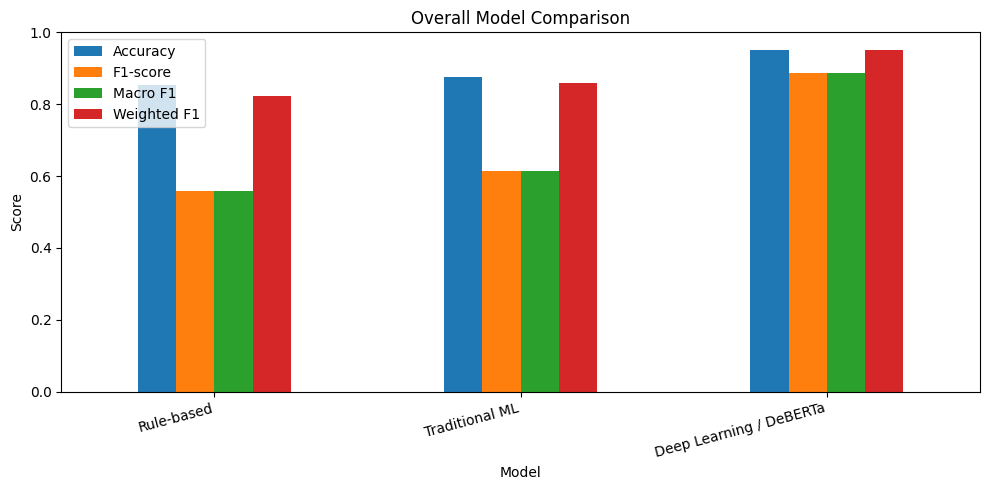

In [26]:
chart_df = overall_metrics.set_index("Model")[["Accuracy", "F1-score", "Macro F1", "Weighted F1"]]
ax = chart_df.plot(kind="bar", figsize=(10, 5))
ax.set_title("Overall Model Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 9. Macro F1 by Aspect

This chart shows which aspects are easier or harder for each method.

Usually, `Food` has better performance because it has more training examples. `Price` and `Eating Environment / Ambiance` can be harder because they have fewer positive and negative examples.

Model,Deep Learning / DeBERTa,Rule-based,Traditional ML
Aspect,,,
Eating Environment / Ambiance,0.8534,0.4952,0.5326
Food,0.8970,0.5115,0.6600
Price,0.8905,0.6693,0.5483
Service,0.8692,0.5796,0.5863


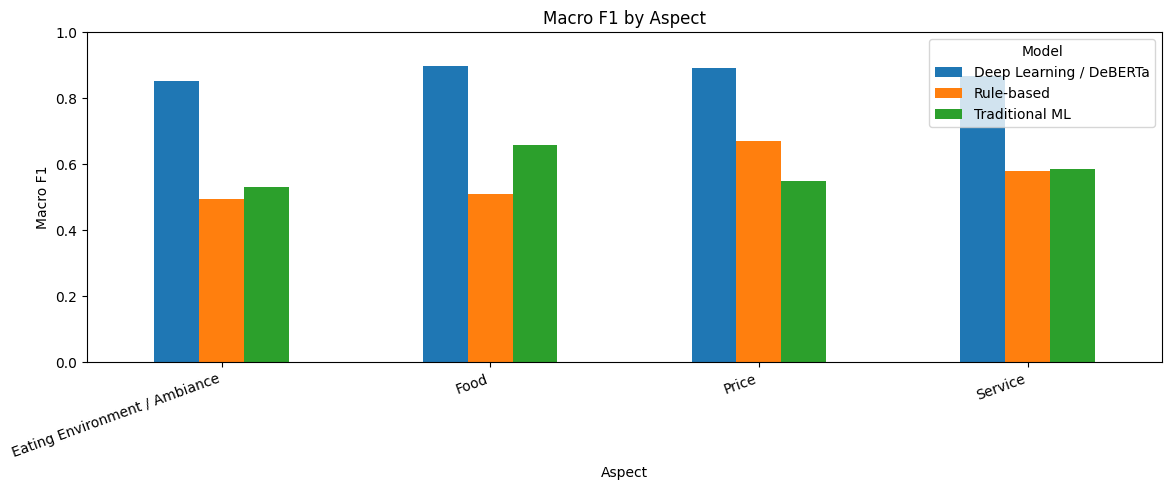

In [27]:
aspect_metrics = all_metrics[all_metrics["Aspect"] != "Overall"].copy()
pivot_macro = aspect_metrics.pivot(index="Aspect", columns="Model", values="Macro F1")
display(pivot_macro.round(4))

ax = pivot_macro.plot(kind="bar", figsize=(12, 5))
ax.set_title("Macro F1 by Aspect")
ax.set_xlabel("Aspect")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 10. Per-label Result

This section checks performance for each label.

This is important because a model can get high accuracy by predicting many `Unknown` labels, but the real task also needs good `Positive` and `Negative` detection.

In [28]:
def per_label_table(model_name, y_true, y_pred):
    report = classification_report(y_true, y_pred, labels=LABELS, output_dict=True, zero_division=0)
    rows = []
    for label in LABELS:
        rows.append({
            "Model": model_name,
            "Label": label,
            "Precision": report[label]["precision"],
            "Recall": report[label]["recall"],
            "F1": report[label]["f1-score"],
            "Support": report[label]["support"],
        })
    return pd.DataFrame(rows)

label_frames = []
if rule_true is not None:
    label_frames.append(per_label_table("Rule-based", rule_true, rule_pred))
label_frames.append(per_label_table("Traditional ML", traditional_true, traditional_pred))
if deberta_true is not None:
    label_frames.append(per_label_table("Deep Learning / DeBERTa", deberta_true, deberta_pred))

per_label_df = pd.concat(label_frames, ignore_index=True)
display(per_label_df.round(4))

,Model,Label,Precision,Recall,F1,Support
0,Rule-based,Positive,0.7186,0.3136,0.4366,456.0
1,Rule-based,Negative,0.8333,0.1970,0.3187,203.0
2,Rule-based,Unknown,0.8608,0.9793,0.9162,2993.0
3,Traditional ML,Positive,0.7391,0.5219,0.6118,456.0
4,Traditional ML,Negative,0.6393,0.1921,0.2955,203.0
5,Traditional ML,Unknown,0.8951,0.9776,0.9345,2993.0
6,Deep Learning / DeBERTa,Positive,0.7941,0.9386,0.8603,456.0
7,Deep Learning / DeBERTa,Negative,0.8870,0.7734,0.8263,203.0
8,Deep Learning / DeBERTa,Unknown,0.9823,0.9636,0.9728,2993.0


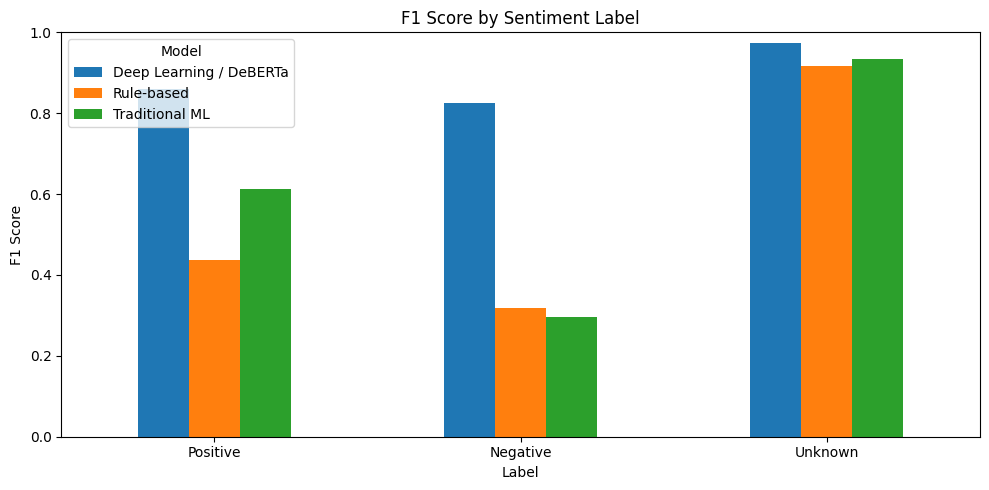

In [29]:
pivot_label_f1 = per_label_df.pivot(index="Label", columns="Model", values="F1").reindex(LABELS)
ax = pivot_label_f1.plot(kind="bar", figsize=(10, 5))
ax.set_title("F1 Score by Sentiment Label")
ax.set_xlabel("Label")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Mentioned-Aspect Evaluation

The full dataset has many `Unknown` labels because most reviews do not mention every aspect.

For example, a review may talk about food and service, but not price or ambiance. In that case, price and ambiance are correctly labeled as `Unknown`.

This is normal for ABSA, but it can make accuracy and weighted F1 look high. To better compare the three methods, this section evaluates only the cases where the true label is `Positive` or `Negative`.

This answers a more focused question:

> When an aspect is actually mentioned, how well can each method classify its sentiment?

This does not replace the full evaluation. It is an additional analysis to make the model differences clearer.

In [30]:
def mentioned_only_metrics(model_name, y_true, y_pred):
    filtered_true = []
    filtered_pred = []

    for true_label, pred_label in zip(y_true, y_pred):
        if true_label != "Unknown":
            filtered_true.append(true_label)
            filtered_pred.append(pred_label)

    precision, recall, f1, _ = precision_recall_fscore_support(
        filtered_true,
        filtered_pred,
        labels=["Positive", "Negative"],
        average="macro",
        zero_division=0,
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        filtered_true,
        filtered_pred,
        labels=["Positive", "Negative"],
        average="weighted",
        zero_division=0,
    )

    return {
        "Model": model_name,
        "Examples": len(filtered_true),
        "Accuracy": accuracy_score(filtered_true, filtered_pred),
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Macro F1": f1,
        "Weighted F1": weighted_f1,
    }

mentioned_rows = []
if rule_true is not None:
    mentioned_rows.append(mentioned_only_metrics("Rule-based", rule_true, rule_pred))
mentioned_rows.append(mentioned_only_metrics("Traditional ML", traditional_true, traditional_pred))
if deberta_true is not None:
    mentioned_rows.append(mentioned_only_metrics("Deep Learning / DeBERTa", deberta_true, deberta_pred))

mentioned_metrics_df = pd.DataFrame(mentioned_rows)
display(mentioned_metrics_df.round(4))

,Model,Examples,Accuracy,Precision,Recall,F1-score,Macro F1,Weighted F1
0,Rule-based,659,0.2777,0.9931,0.2553,0.4025,0.4025,0.4307
1,Traditional ML,659,0.4203,0.8374,0.3570,0.4838,0.4838,0.5512
2,Deep Learning / DeBERTa,659,0.8877,0.9694,0.8560,0.9065,0.9065,0.9224


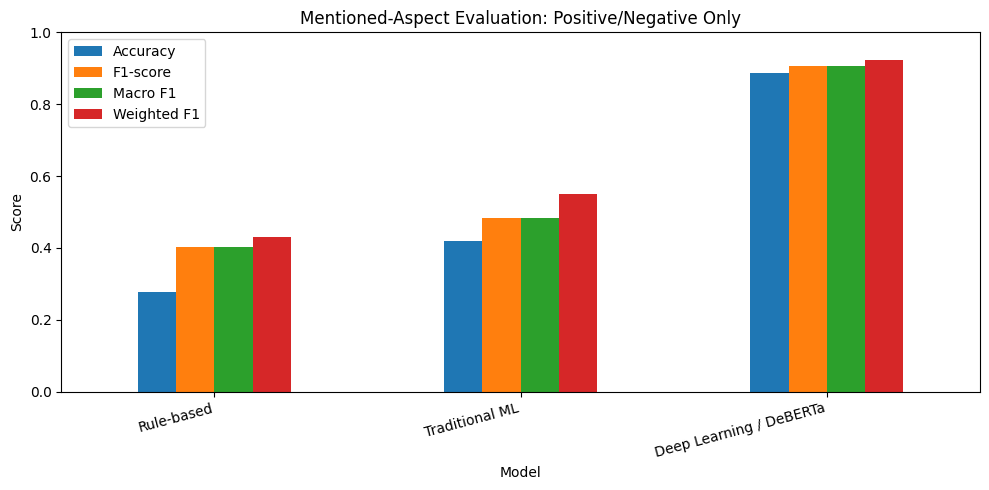

In [31]:
mentioned_chart_df = mentioned_metrics_df.set_index("Model")[["Accuracy", "F1-score", "Macro F1", "Weighted F1"]]
ax = mentioned_chart_df.plot(kind="bar", figsize=(10, 5))
ax.set_title("Mentioned-Aspect Evaluation: Positive/Negative Only")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### How to Explain This Result

Use both evaluations in the report:

- **Full evaluation** checks whether the system correctly predicts `Positive`, `Negative`, and `Unknown` for every aspect.
- **Mentioned-aspect evaluation** checks sentiment classification only when the aspect is truly mentioned.

This is fairer than removing `Unknown` completely because `Unknown` is still part of the real task. The second chart simply helps show the difference between methods more clearly.

## 12. Confusion Matrix

The confusion matrix shows what kind of mistakes each model makes.

Rows are the true labels. Columns are the predicted labels.

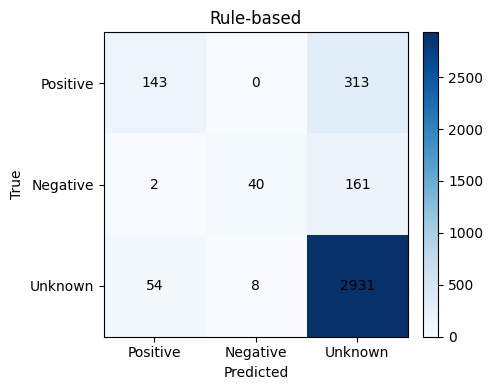

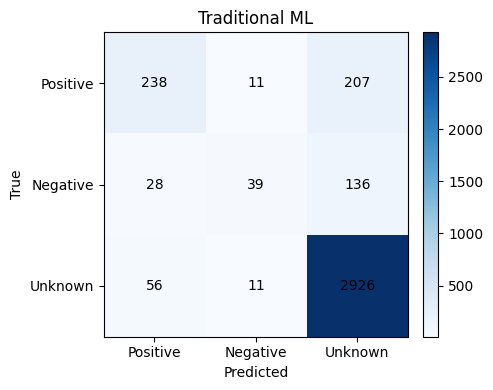

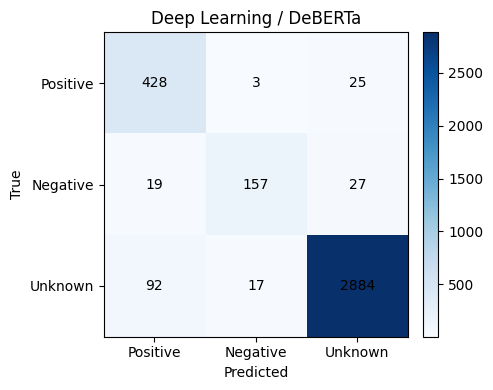

In [32]:
def plot_confusion(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(model_name)
    ax.set_xticks(range(len(LABELS)))
    ax.set_yticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS)
    ax.set_yticklabels(LABELS)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

if rule_true is not None:
    plot_confusion("Rule-based", rule_true, rule_pred)
plot_confusion("Traditional ML", traditional_true, traditional_pred)
if deberta_true is not None:
    plot_confusion("Deep Learning / DeBERTa", deberta_true, deberta_pred)

## 13. Simple Explanation for Report

You can use this explanation in your report:

> The project evaluates three methods: a rule-based baseline, a traditional machine learning model, and a deep learning transformer model. All methods are tested on the same 30% held-out testing split from the processed restaurant ABSA dataset. The evaluation uses accuracy, precision, recall, F1-score, macro F1, weighted F1, and an additional mentioned-aspect evaluation for Positive/Negative labels. In this project, the reported F1-score is the macro-averaged F1-score because the task has three sentiment labels: `Positive`, `Negative`, and `Unknown`. Macro F1 is the most important metric because the dataset is imbalanced and contains many `Unknown` labels. A high macro F1 means the model performs more consistently across all sentiment labels, instead of only performing well on the majority class.
>
> The rule-based method is easy to explain because it uses predefined aspect keywords and sentiment rules, but it is limited when the sentence structure is complex. The traditional machine learning model performs better because it learns patterns from the dataset. The deep learning method uses DeBERTa-v3-base, which understands more context and usually gives the best overall result. Therefore, DeBERTa is selected as the strongest method for the final demo, while the other methods are useful for comparison and explanation.

## 14. Final Notes

This notebook gives fresh evaluation results using a 70% training / 30% testing setup. It retrains only the Traditional ML baseline because that is fast. It does not retrain DeBERTa.

Retraining is only needed if you change one of these things:

- the dataset
- the preprocessing
- the model type
- the model training settings
- the train/test split

If nothing changes, this notebook is enough to regenerate current evaluation tables and charts.